# Decaying Turbulence — Dedicated Analysis Sweep

This notebook focuses exclusively on **decaying turbulence**.

Goals:
1. **Time-evolution sweep** — vary `R` (turbulence duration proxy) to show how the spectrum evolves;
   separate figures for $M = 0.1$ and $M = 1.0$.
2. **Power-law fits** — fit two power laws (IR region and inertial range) to the full-band spectrum,
   avoiding the decaying peak region.
3. **Inertial-range zoom** — high-resolution grid in $f \in [10^{-4}, 10^{-2}]$ Hz to resolve
   the inertial range without numerical artefacts.

> **Note on vertical lines**: the `normalized_strain` function uses `np.nan` for non-positive
> values so that matplotlib skips them cleanly on log plots.

## 1. Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from gw_turbulence import H_pq_decaying, LiveStatusLogger

%matplotlib inline

out_dir = os.path.abspath('outputs')
os.makedirs(out_dir, exist_ok=True)

# ── Physical constants ────────────────────────────────────────────────────────
k0_dec     = 1.0
M_compare  = [0.1, 1.0]
M_colors   = {0.1: 'C0', 1.0: 'C2'}
FREQ_SCALE = 1.55e-3   # f_Hz = FREQ_SCALE * q

# ── R sweep: proxy for turbulence duration ────────────────────────────────────
# Larger R → lower integration bound (1/R) → longer-lived turbulence source.
# The low-frequency break visible near 6e-9 Hz shifts with R.
R_sweep  = [1e2, 3e2, 1e3, 3e3, 1e4]
R_labels = [
    r'$R=10^2$',
    r'$R=3\!\times\!10^2$',
    r'$R=10^3$',
    r'$R=3\!\times\!10^3$',
    r'$R=10^4$',
]
R_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(R_sweep)))

# ── Full-band grid (IR break + inertial range) ────────────────────────────────
# Extra density around the break region (q ~ 3e-6, f ~ 6e-9 Hz)
qs_full = np.unique(np.concatenate([
    np.logspace(np.log10(1e-11), np.log10(1e-4), 20),   # deep IR
    np.logspace(np.log10(1e-4),  np.log10(5e-3), 10),   # break region
    np.logspace(np.log10(5e-3),  np.log10(10.0), 20),   # inertial + peak
]))
freq_full = FREQ_SCALE * qs_full

# ── High-resolution inertial-range grid ──────────────────────────────────────
# q in [0.06, 7]  →  f in [~9e-5, ~1.1e-2] Hz
qs_inert   = np.logspace(np.log10(6e-2), np.log10(7.0), 50)
freq_inert = FREQ_SCALE * qs_inert

print(f'Full-band grid:      {len(qs_full):3d} q-pts  '
      f'[{qs_full.min():.1e}, {qs_full.max():.1e}]')
print(f'Inertial-range grid: {len(qs_inert):3d} q-pts  '
      f'[{qs_inert.min():.1e}, {qs_inert.max():.1e}]')
print(f'  → f in [{freq_inert.min():.1e}, {freq_inert.max():.1e}] Hz')

Full-band grid:       48 q-pts  [1.0e-11, 1.0e+01]
Inertial-range grid:  50 q-pts  [6.0e-02, 7.0e+00]
  → f in [9.3e-05, 1.1e-02] Hz


## 2. Compute / load decaying spectra

Each cache file stores an array of shape `(n_R, n_M, n_q)`.
If the grid and parameter arrays match, the cache is reused without recomputing.

In [2]:
def load_or_compute(
    cache_path, qs, R_list, M_list, k0=1.0,
    conv_pts=14, x_pts=5, y_pts=5,
):
    """Return h array of shape (n_R, n_M, n_q), loading from cache if valid."""
    R_arr = np.array(R_list, dtype=float)
    M_arr = np.array(M_list, dtype=float)

    if os.path.exists(cache_path):
        d = np.load(cache_path)
        if (
            'qs' in d and 'R_sweep' in d and 'M_compare' in d
            and np.array_equal(d['qs'], qs)
            and np.array_equal(d['R_sweep'], R_arr)
            and np.array_equal(d['M_compare'], M_arr)
        ):
            print(f'Cache hit: {os.path.basename(cache_path)}')
            return d['h_dec']
        print(f'Cache mismatch — recomputing: {os.path.basename(cache_path)}')

    status = LiveStatusLogger(prefix='dec-sweep', every_seconds=15.0)
    h = np.zeros((len(R_list), len(M_list), len(qs)))

    for r_idx, R in enumerate(R_list):
        for m_idx, M in enumerate(M_list):
            print(f'  R={R:.0e}  M={M}  ({len(qs)} q-pts) …')
            for i, q in enumerate(qs):
                h[r_idx, m_idx, i] = H_pq_decaying(
                    q, q, M=M, R=R, k0=k0,
                    convolution_method='trapz',
                    convolution_points=conv_pts,
                    integration_method='sampled',
                    x_points=x_pts,
                    y_points=y_pts,
                    status=status,
                )

    np.savez(cache_path, qs=qs, R_sweep=R_arr, M_compare=M_arr, h_dec=h, k0=k0)
    print(f'Saved: {os.path.basename(cache_path)}')
    return h


# ── Full-band R sweep ─────────────────────────────────────────────────────────
h_full = load_or_compute(
    os.path.join(out_dir, 'dec_sweep_full_band.npz'),
    qs_full, R_sweep, M_compare,
    conv_pts=14, x_pts=5, y_pts=5,
)

# ── High-res inertial-range sweep ─────────────────────────────────────────────
h_inert = load_or_compute(
    os.path.join(out_dir, 'dec_sweep_inertial.npz'),
    qs_inert, R_sweep, M_compare,
    conv_pts=22, x_pts=8, y_pts=8,
)

print()
print(f'h_full  shape: {h_full.shape}   (n_R, n_M, n_q_full)')
print(f'h_inert shape: {h_inert.shape}  (n_R, n_M, n_q_inert)')

Cache hit: dec_sweep_full_band.npz
Cache hit: dec_sweep_inertial.npz

h_full  shape: (5, 2, 48)   (n_R, n_M, n_q_full)
h_inert shape: (5, 2, 50)  (n_R, n_M, n_q_inert)


## 3. Normalized strain

Using `np.nan` for non-positive values prevents matplotlib from drawing
spurious vertical lines where the spectrum touches zero near the spectral cutoff.

In [3]:
def normalized_strain(q_vals, h_vals, M):
    """Gogoberidze-style normalized characteristic strain.
    Non-positive q*H values become NaN (skipped on log plots)."""
    val = q_vals * h_vals
    return 1.62e-18 * np.sqrt(np.where(val > 0, val, np.nan)) / M**1.5


# Pre-compute all strain arrays:  shape (n_R, n_M, n_q)
sc_full = np.array([
    [normalized_strain(qs_full,  h_full[r, m],  M)
     for m, M in enumerate(M_compare)]
    for r in range(len(R_sweep))
])

sc_inert = np.array([
    [normalized_strain(qs_inert, h_inert[r, m], M)
     for m, M in enumerate(M_compare)]
    for r in range(len(R_sweep))
])

print('Strain arrays computed.')
print(f'sc_full  shape: {sc_full.shape}')
print(f'sc_inert shape: {sc_inert.shape}')

Strain arrays computed.
sc_full  shape: (5, 2, 48)
sc_inert shape: (5, 2, 50)


## 4. Time-evolution plots — one figure per $M$

Each curve shows the decaying-turbulence spectrum for a different value of $R$
(the turbulence duration parameter).  Larger $R$ means the source is active for
longer, which shifts the IR break at $\approx 6\times10^{-9}$ Hz to lower frequencies
and boosts the overall amplitude.

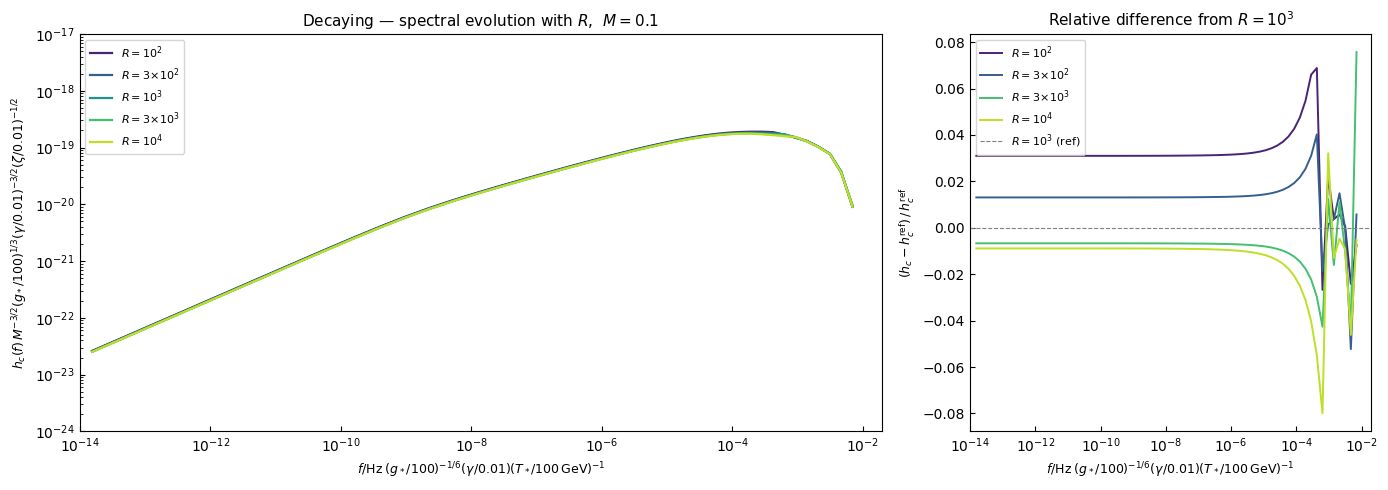

Saved: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/dec_time_evolution_M0p1.pdf


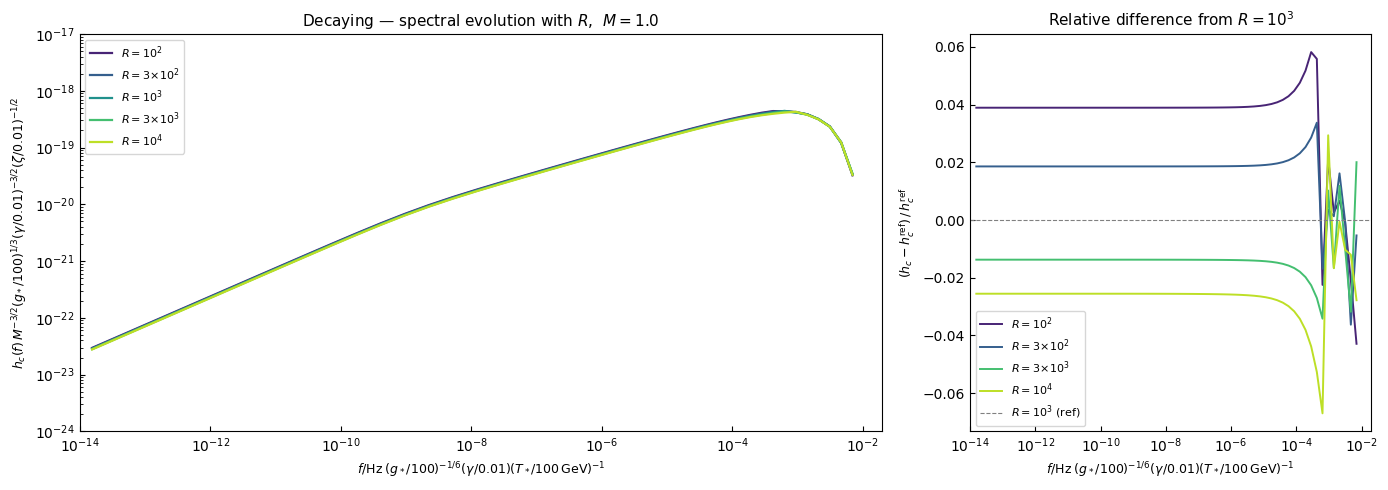

Saved: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/dec_time_evolution_M1p0.pdf


In [4]:

YLABEL = (r'$h_c(f)\,M^{-3/2}(g_*/100)^{1/3}'
          r'(\gamma/0.01)^{-3/2}(\zeta/0.01)^{-1/2}$')
XLABEL = (r'$f/\mathrm{Hz}\;(g_*/100)^{-1/6}'
          r'(\gamma/0.01)(T_*/100\,\mathrm{GeV})^{-1}$')

# Reference curve index for relative differences (R = 10^3, middle of sweep)
REF_IDX = 2   # R_sweep[2] = 1e3

for m_idx, M in enumerate(M_compare):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                             gridspec_kw={'width_ratios': [2, 1]})

    # ── Left panel: absolute spectra ──────────────────────────────────────────
    ax = axes[0]
    for r_idx, (label, col) in enumerate(zip(R_labels, R_colors)):
        ax.loglog(freq_full, sc_full[r_idx, m_idx],
                  color=col, lw=1.6, label=label)

    ax.set_xlim(1e-14, 2e-2)
    ax.set_ylim(1e-24, 1e-17)
    ax.set_xlabel(XLABEL, fontsize=9)
    ax.set_ylabel(YLABEL, fontsize=9)
    ax.set_title(fr'Decaying — spectral evolution with $R$,  $M = {M}$', fontsize=11)
    ax.legend(fontsize=8)
    ax.tick_params(which='both', direction='in')

    # ── Right panel: relative difference from R = 10^3 ────────────────────────
    # Shows the small but real R-dependence on a linear scale
    ax = axes[1]
    sc_ref_curve = sc_full[REF_IDX, m_idx]
    for r_idx, (label, col) in enumerate(zip(R_labels, R_colors)):
        if r_idx == REF_IDX:
            continue   # skip the reference itself
        delta = (sc_full[r_idx, m_idx] - sc_ref_curve) / sc_ref_curve
        # only plot where reference is valid
        valid = np.isfinite(sc_ref_curve) & np.isfinite(delta) & (sc_ref_curve > 0)
        ax.semilogx(freq_full[valid], delta[valid], color=col, lw=1.4, label=label)

    ax.axhline(0, color='0.5', lw=0.8, ls='--', label=fr'$R=10^3$ (ref)')
    ax.set_xlim(1e-14, 2e-2)
    ax.set_xlabel(XLABEL, fontsize=9)
    ax.set_ylabel(r'$(h_c - h_c^{\rm ref})\,/\,h_c^{\rm ref}$', fontsize=9)
    ax.set_title('Relative difference from $R=10^3$', fontsize=11)
    ax.legend(fontsize=8)
    ax.tick_params(which='both', direction='in')

    fig.tight_layout()
    plt.show()

    fname = os.path.join(
        out_dir,
        f'dec_time_evolution_M{str(M).replace(".", "p")}.pdf'
    )
    fig.savefig(fname)
    print(f'Saved: {fname}')


## 5. Power-law fits — IR and inertial regions

Two power-law fits are overlaid on the full-band spectrum:
- **IR region**: $f < 4\times10^{-9}$ Hz (below the broken-power-law break).
- **Inertial region**: $10^{-4}$ Hz $< f < 2\times10^{-3}$ Hz (avoids the decay/peak region).

Fits use the longest-lived curve ($R = 10^4$) as the reference.

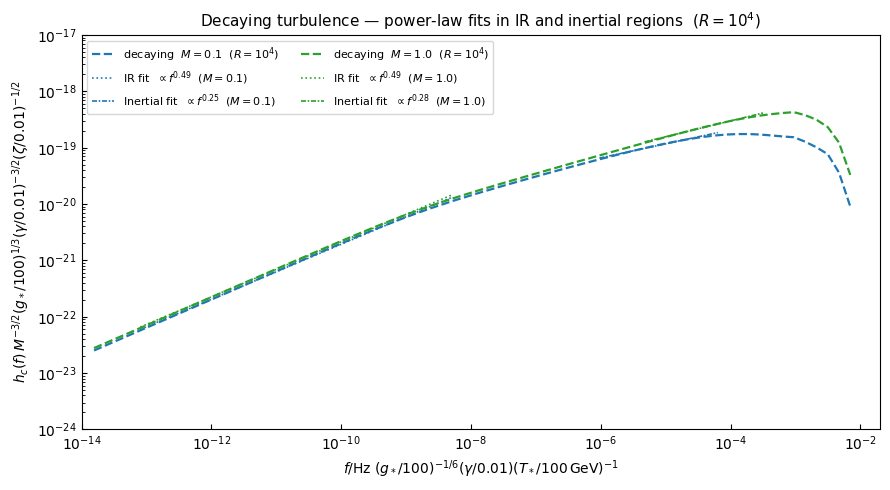

Saved: dec_power_law_fits.pdf


In [5]:
def fit_powerlaw(f, sc, f_lo, f_hi):
    """Least-squares power-law fit in log-log space over [f_lo, f_hi].
    Returns (alpha, log10_A) or None if fewer than 3 valid points."""
    mask = np.isfinite(sc) & (sc > 0) & (f >= f_lo) & (f <= f_hi)
    if mask.sum() < 3:
        return None
    popt, _ = curve_fit(
        lambda lf, a, c: a * lf + c,
        np.log10(f[mask]), np.log10(sc[mask])
    )
    return popt  # (alpha, log10_A)


REF_R = -1  # index of R = 10^4 (longest-lived)

fig, ax = plt.subplots(figsize=(9, 5))

for m_idx, M in enumerate(M_compare):
    sc  = sc_full[REF_R, m_idx]
    col = M_colors[M]

    ax.loglog(freq_full, sc, color=col, lw=1.6, ls='--',
              label=fr'decaying  $M={M}$  ($R=10^4$)')

    # IR fit  (f < 4e-9 Hz)
    p_ir = fit_powerlaw(freq_full, sc, 1e-13, 4e-9)
    if p_ir is not None:
        f_ir  = np.logspace(np.log10(8e-14), np.log10(5e-9), 100)
        label_ir = fr'IR fit  $\propto f^{{{p_ir[0]:.2f}}}$  ($M={M}$)'
        ax.loglog(f_ir,
                  10**(p_ir[0] * np.log10(f_ir) + p_ir[1]),
                  color=col, lw=1.2, ls=':',
                  label=label_ir)

    # Inertial fit — detect spectral peak and fit the rising slope *before* it
    valid_sc = np.isfinite(sc) & (sc > 0)
    if valid_sc.sum() > 0:
        f_peak = freq_full[valid_sc][np.nanargmax(sc[valid_sc])]
        p_in = fit_powerlaw(freq_full, sc, f_peak / 100, f_peak / 5)
        if p_in is not None:
            f_in  = np.logspace(np.log10(f_peak / 200), np.log10(f_peak / 3), 100)
            label_in = fr'Inertial fit  $\propto f^{{{p_in[0]:.2f}}}$  ($M={M}$)'
            ax.loglog(f_in,
                      10**(p_in[0] * np.log10(f_in) + p_in[1]),
                      color=col, lw=1.2, ls=(0, (3, 1, 1, 1)),
                      label=label_in)

ax.set_xlim(1e-14, 2e-2)
ax.set_ylim(1e-24, 1e-17)
ax.set_xlabel(XLABEL, fontsize=10)
ax.set_ylabel(YLABEL, fontsize=10)
ax.set_title(
    'Decaying turbulence — power-law fits in IR and inertial regions'
    r'  ($R = 10^4$)',
    fontsize=11)
ax.legend(fontsize=8, ncol=2)
ax.tick_params(which='both', direction='in')
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(out_dir, 'dec_power_law_fits.pdf'))
print('Saved: dec_power_law_fits.pdf')

## 6. Inertial-range zoom — high-resolution, one figure per $M$

Uses the dedicated 50-point inertial-range grid ($q \in [0.06, 7]$) with
higher integration resolution to resolve the spectral shape in
$f \in [10^{-4}, 10^{-2}]$ Hz without numerical artefacts.

A power-law fit is overlaid on the longest-lived ($R = 10^4$) curve.

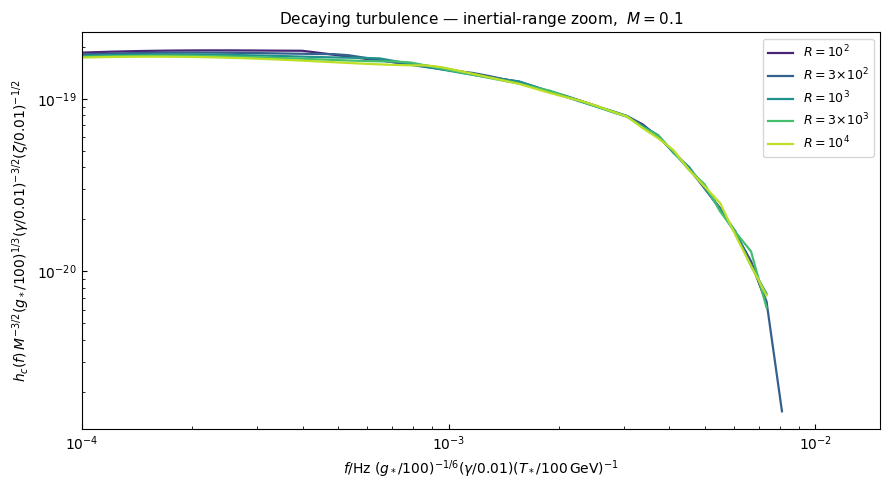

Saved: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/dec_inertial_zoom_M0p1.pdf


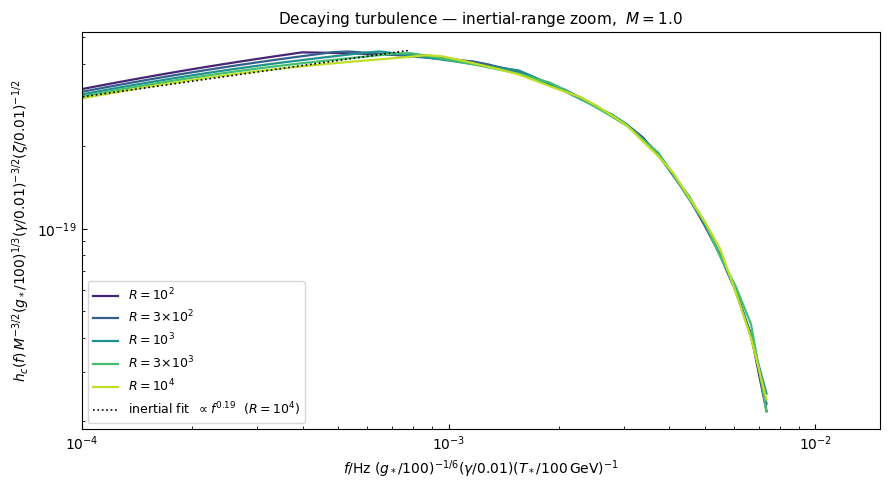

Saved: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/dec_inertial_zoom_M1p0.pdf


In [6]:
for m_idx, M in enumerate(M_compare):
    fig, ax = plt.subplots(figsize=(9, 5))

    for r_idx, (label, col) in enumerate(zip(R_labels, R_colors)):
        ax.loglog(freq_inert, sc_inert[r_idx, m_idx],
                  color=col, lw=1.6, label=label)

    # Power-law fit — detect peak and fit the rising slope below it
    sc_ref = sc_inert[REF_R, m_idx]
    valid_mask = np.isfinite(sc_ref) & (sc_ref > 0)
    if valid_mask.sum() > 0:
        f_peak = freq_inert[valid_mask][np.nanargmax(sc_ref[valid_mask])]
        # Use the inertial-grid lower bound as the fit floor to stay in-range
        f_lo_fit = max(freq_inert[0], f_peak / 20)
        f_hi_fit = min(f_peak * 0.6, freq_inert[-1])
        p_in = fit_powerlaw(freq_inert, sc_ref, f_lo_fit, f_hi_fit)
        if p_in is not None:
            f_fit = np.logspace(np.log10(f_lo_fit * 0.8), np.log10(f_hi_fit * 1.5), 150)
            ax.loglog(
                f_fit,
                10**(p_in[0] * np.log10(f_fit) + p_in[1]),
                color='k', lw=1.2, ls=':',
                label=fr'inertial fit  $\propto f^{{{p_in[0]:.2f}}}$  ($R=10^4$)'
            )

    ax.set_xlim(1e-4, 1.5e-2)
    ax.set_xlabel(XLABEL, fontsize=10)
    ax.set_ylabel(YLABEL, fontsize=10)
    ax.set_title(
        fr'Decaying turbulence — inertial-range zoom,  $M = {M}$',
        fontsize=11)
    ax.legend(fontsize=9)
    ax.tick_params(which='both', direction='in')
    fig.tight_layout()
    plt.show()

    fname = os.path.join(
        out_dir,
        f'dec_inertial_zoom_M{str(M).replace(".", "p")}.pdf'
    )
    fig.savefig(fname)
    print(f'Saved: {fname}')